In [1]:
import numpy as np
import pandas as pd

n_samples = 1000
np.random.seed(100)

data = {
        'order_id': list(range(1000, 1000 + n_samples)),
        'distance_km': np.round(np.random.uniform(1, 25, n_samples), 1),
        'prep_time_min': np.random.randint(5, 45, n_samples),
        'courier_wait_time_min': np.random.randint(2, 30, n_samples),
        'order_value_toman': np.random.randint(200, 10000, n_samples) * 1000,
        'is_peak_hour': np.random.choice([0, 1], size=n_samples, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

cancellation_score = (
        0.03 * df['distance_km'] +
        0.02 * df['prep_time_min'] +
        0.05 * df['courier_wait_time_min'] +
        0.15 * df['is_peak_hour']
)

cancel_prob = 1 / (1 + np.exp(-(cancellation_score - 2)))
df['is_cancelled'] = (np.random.rand(n_samples) < cancel_prob).astype(int)

df.head()

,order_id,distance_km,prep_time_min,courier_wait_time_min,order_value_toman,is_peak_hour,is_cancelled
0,1000,14.0,38,19,1177000,0,0
1,1001,7.7,31,10,796000,0,1
2,1002,11.2,37,11,6877000,1,0
3,1003,21.3,25,2,1026000,0,0
4,1004,1.1,8,29,3173000,0,1


In [2]:
import sqlite3
from IPython.display import display

conn = sqlite3.connect(':memory:')
df.to_sql('deliveries', conn, index=False)

sql_query = """
SELECT 
    CASE 
        WHEN distance_km < 3 THEN 'Short Distance (<3km)'
        WHEN distance_km BETWEEN 3 AND 7 THEN 'Medium Distance (3-7km)'
        ELSE 'Long Distance (>7km)'
    END AS distance_category,
    COUNT(*) as total_orders,
    SUM(is_cancelled) as cancelled_orders,
    ROUND(AVG(is_cancelled) * 100, 2) as cancellation_rate_percentage
FROM deliveries
GROUP BY distance_category
ORDER BY cancellation_rate_percentage DESC;
"""

sql_result = pd.read_sql_query(sql_query, conn)
print("SQL Analysis: Cancellation Rate by Delivery Distance")
display(sql_result)

SQL Analysis: Cancellation Rate by Delivery Distance


,distance_category,total_orders,cancelled_orders,cancellation_rate_percentage
0,Long Distance (>7km),749,348,46.46
1,Medium Distance (3-7km),175,73,41.71
2,Short Distance (<3km),76,30,39.47


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df[['distance_km', 'prep_time_min', 'courier_wait_time_min', 'is_peak_hour']]
y = df['is_cancelled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.63

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.77      0.70       111
           1       0.61      0.46      0.53        89

    accuracy                           0.63       200
   macro avg       0.63      0.61      0.61       200
weighted avg       0.63      0.63      0.62       200



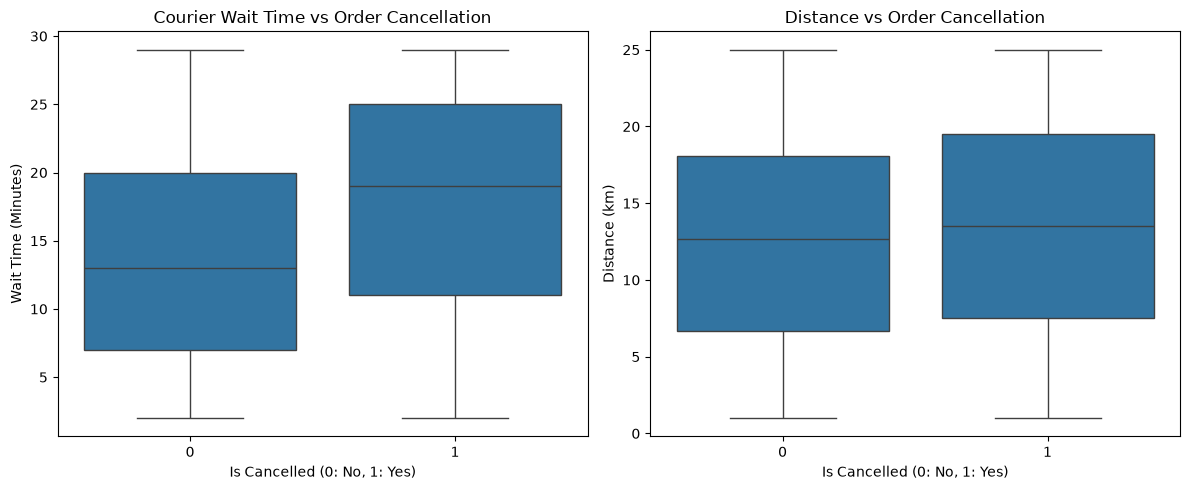

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='is_cancelled', y='courier_wait_time_min', data=df)
plt.title('Courier Wait Time vs Order Cancellation')
plt.xlabel('Is Cancelled (0: No, 1: Yes)')
plt.ylabel('Wait Time (Minutes)')

plt.subplot(1, 2, 2)
sns.boxplot(x='is_cancelled', y='distance_km', data=df)
plt.title('Distance vs Order Cancellation')
plt.xlabel('Is Cancelled (0: No, 1: Yes)')
plt.ylabel('Distance (km)')

plt.tight_layout()
plt.show()